In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install shap -q
!pip install hydra-core -q
!pip install fedlab -q
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import random
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import copy
import statistics
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import yaml
import os
from fedlab.utils.dataset.partition import  BasicPartitioner
from torch.utils.data import Subset
import matplotlib.pyplot as plt
from collections import OrderedDict
import concurrent.futures
from concurrent.futures import ThreadPoolExecutor, as_completed
import shap
import hydra
from hydra.core.hydra_config import HydraConfig
from omegaconf import DictConfig, OmegaConf
import random
import numpy as np
import torch
# Set seed for Python's random module
random.seed(42)
# Set seed for NumPy
np.random.seed(42)
# Set seed for PyTorch
torch.manual_seed(42)
import numpy as np
import torch
import torch.nn.functional as F
import random
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import os
import seaborn as sns
# If you are using CUDA, you may also want to set the seed for GPU operations
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)  # For all GPUs if you have multiple



- num_rounds: 5 # number of FL rounds in the experiment
- num_clients: 30 # number of total clients
- num_edges: 5

config_fit: # a config that each client will receive. This is sent by the server. This will dynamically configure the training on the client side as the simulation progresses.
- lr: 0.01 # learning rate to used by the clients
- momentum: 0.9 # momentum used by SGD optimiser on the client side
- local_epochs: 10 # training epochs each client executes in a fit() round
- batch_size: 64 # batch size to use by clients during training

### 1. Load and preprocess the dataset. Get Training and test dataset

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_flag_distribution(df, class_labels=None):
    """
    Plots the distribution of the 'flag' column in the dataset.

    Parameters:
        df (pd.DataFrame): The dataframe containing the 'flag' column.
        class_labels (dict, optional): A dictionary to map flag values to meaningful class names.
                                       Example: {"R": "Normal", "T": "Attack"}.
    """
    sns.countplot(x="label", data=df, palette="viridis", hue="label", legend=False)
    plt.title("Flag Value Counts")
    if class_labels:
        plt.xticks(
            ticks=range(len(class_labels)),
            labels=[class_labels[label] for label in class_labels]
        )
    plt.show()

def preprocess_dataset():
    processed_file = "/content/drive/MyDrive/car_hacking_dataset/Dataset/Car_Hacking_preprocessed_dataset.csv"
    class_labels = {"R": "Normal", "T": "Attack"}

    # Load processed dataset if it exists
    if os.path.isfile(processed_file):
        df = pd.read_csv(processed_file)
        if "flag" in df.columns and "label" not in df.columns:
            df.rename(columns={"flag": "label"}, inplace=True)
        plot_flag_distribution(df, class_labels)
        return df

    # Raw data file paths
    raw_files = {
        "normal": "/content/drive/MyDrive/Normal_data.csv",
        "dos": "/content/drive/MyDrive/DoS_dataset.csv",
        "fuzzy": "/content/drive/MyDrive/Fuzzy_dataset.csv",
        "gear": "/content/drive/MyDrive/gear_dataset.csv",
        "rpm": "/content/drive/MyDrive/RPM_dataset.csv"
    }

    column_names = ["Timestamp", "ID", "DLC", "Byte1", "Byte2", "Byte3", "Byte4", "Byte5", "Byte6", "Byte7", "Byte8", "flag"]
    dataframes = []

    # Load and process raw files
    for key, path in raw_files.items():
        df = pd.read_csv(path, names=column_names, index_col=False) if key != "normal" else pd.read_csv(path, index_col=False)
        if key == "normal":
            df["flag"] = "R"  # Assign flag for normal data
        dataframes.append(df)

    # Combine all datasets
    df = pd.concat(dataframes, axis=0, ignore_index=True)
    print(f"Total data shape before removing missing data: {df.shape}")

    # Drop rows with missing data
    df.dropna(inplace=True)
    print(f"Total data shape after removing missing data: {df.shape}")

    # Convert Hexadecimal Byte columns to Decimal and drop original Byte columns
    byte_columns = [f"Byte{i}" for i in range(1, 9)]
    for i, byte_col in enumerate(byte_columns):
        df[f"DATA_{i}"] = df[byte_col].apply(lambda x: int(str(x), 16))
    df.drop(columns=byte_columns, inplace=True)

    # Drop unnecessary columns
    df.drop(columns=["Timestamp", "ID", "DLC"], inplace=True)

    # Remove duplicate rows
    df.drop_duplicates(inplace=True)
    print(f"Data shape after removing duplicate entries: {df.shape}")

    # Save the processed dataset
    os.makedirs(os.path.dirname(processed_file), exist_ok=True)
    df.to_csv(processed_file, index=False)

    # Visualize and rename flag column
    plot_flag_distribution(df, class_labels)
    if "flag" in df.columns and "label" not in df.columns:
        df.rename(columns={"flag": "label"}, inplace=True)

    return df

In [ ]:
def prepare_training_testing_data(dataset, test_size=0.30, output_dir="/content/drive/MyDrive/car_hacking_dataset/Dataset"):
    """
    Prepares and pre-processes the dataset for training and testing.

    This function shuffles the dataset, encodes labels, scales features, and splits the data
    into training and testing sets. It also saves the processed training and testing data into CSV files.

    Args:
        dataset (pd.DataFrame): The input dataset containing features and labels.
        test_size (float, optional): Proportion of the dataset to be used for testing. Defaults to 0.30.
        output_dir (str, optional): Directory where processed files will be saved. Defaults to a specified path.

    Returns:
        tuple:
            X_train_scaled (numpy.ndarray): Scaled feature matrix for the training set.
            X_test_scaled (numpy.ndarray): Scaled feature matrix for the test set.
    """
    # Shuffle the dataset
    dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

    # Encode labels
    label_mapping = {"R": 0, "T": 1}
    dataset['label'] = dataset['label'].map(label_mapping)

    # Split into train and test sets
    train_df, test_df = train_test_split(dataset, test_size=test_size, stratify=dataset['label'], random_state=42)

    # Split features and labels
    X_train, y_train = train_df.drop(columns=['label']), train_df['label']
    X_test, y_test = test_df.drop(columns=['label']), test_df['label']

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Prepare scaled datasets for saving
    train_df_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    train_df_scaled['label'] = y_train.values

    test_df_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
    test_df_scaled['label'] = y_test.values

    # Save processed datasets
    os.makedirs(output_dir, exist_ok=True)
    train_df_scaled.to_csv(os.path.join(output_dir, "car_hacking_trainset.csv"), index=False)
    test_df_scaled.to_csv(os.path.join(output_dir, "car_hacking_testset.csv"), index=False)

    return X_train_scaled, X_test_scaled

def get_car_hacking_dataset():
    """
    Loads and prepares the CiCiov dataset for training and testing in PyTorch format.

    This function reads the pre-processed train and test CSV files, converts the data into PyTorch tensors,
    and creates TensorDataset objects for both the training and testing data. It also returns the target labels
    separately for both the train and test sets.

    Args:
        None

    Returns:
        tuple:
            train_tensor (torch.utils.data.TensorDataset): Tensor dataset containing training features and labels.
            test_tensor (torch.utils.data.TensorDataset): Tensor dataset containing test features and labels.
            train_target (torch.Tensor): Tensor containing training labels.
            test_target (torch.Tensor): Tensor containing test labels.
    """
    train = pd.read_csv('/content/drive/MyDrive/car_hacking_dataset/Dataset/car_hacking_trainset.csv')
    test = pd.read_csv('/content/drive/MyDrive/car_hacking_dataset/Dataset/car_hacking_testset.csv')
    train_target = torch.tensor(train['label'].values.astype(np.float32))
    train = torch.tensor(train.drop('label', axis = 1).values.astype(np.float32))
    train_tensor = TensorDataset(train, train_target)

    test_target = torch.tensor(test['label'].values.astype(np.float32))
    test = torch.tensor(test.drop('label', axis = 1).values.astype(np.float32))
    test_tensor = TensorDataset(test, test_target)

    return train_tensor , test_tensor ,train_target,test_target

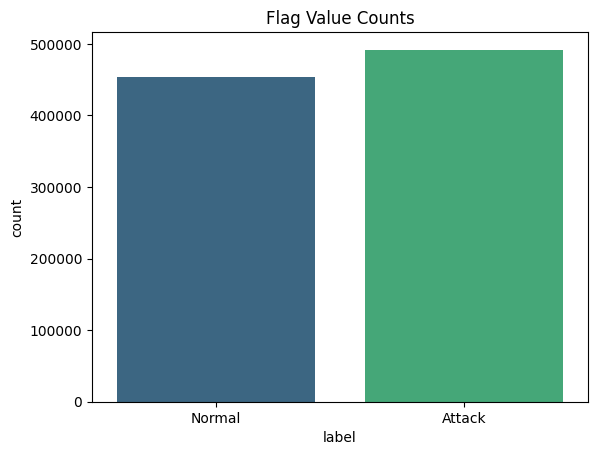

In [ ]:
#  Preprocess the Dataset
df = preprocess_dataset()

# Pre-process the dataset by splitting it into training and testing sets
# The parameter test_size=0.3 indicates that 30% of the data will be used for testing
x_train, x_test = prepare_training_testing_data(df,test_size=0.3)

# Convert the training data (x_train) into a PyTorch tensor of type float32
X_train_tensor = torch.tensor(x_train, dtype=torch.float32)

# Convert the testing data (x_test) into a PyTorch tensor of type float32
X_test_tensor = torch.tensor(x_test, dtype=torch.float32)

# Load the dataset for a specific application (Car-Hacking dataset)
# The function returns training and testing datasets, as well as their corresponding targets
trainset, testset, train_target, test_target = get_car_hacking_dataset()


In [ ]:
x_train.shape, x_test.shape

((662360, 8), (283869, 8))

In [ ]:
print(" Label distribution in the Training data",np.unique(train_target, return_counts=True))
print(" Label distribution in the Test data",np.unique(test_target, return_counts=True))

 Label distribution in the Training data (array([0., 1.], dtype=float32), array([318065, 344295]))
 Label distribution in the Test data (array([0., 1.], dtype=float32), array([136314, 147555]))


### 2. Split the Training set into M parts with M-Number of Clients. Here the test set will not be split. It will be used to test the Global Model.

In [ ]:
import torch
from torch.utils.data import DataLoader, Subset

def get_all_labels(dataset):
    """
    Extract all labels from the given dataset.

    Args:
        dataset (Iterable): The dataset from which to extract labels.
                            It should yield pairs of (data, labels).

    Returns:
        torch.Tensor: A tensor containing all the labels stacked together.
    """
    all_labels = []

    # Iterate through the dataset to collect all labels
    for _, labels in dataset:
        all_labels.append(labels)

    # Stack all labels into a single tensor
    all_labels_tensor = torch.stack(all_labels)

    return all_labels_tensor

def split_dataset(train_set, test_set, num_clients, batch_size, partition, dir_alpha=None, major_classes_num=0):
    """
    Split the dataset into multiple clients for federated learning.

    Args:
        train_set (Dataset): The training dataset to be partitioned.
        test_set (Dataset): The testing dataset.
        num_clients (int): The number of clients to split the data among.
        batch_size (int): The batch size for the data loaders.
        partition (str): The type of partitioning ('iid' for independent and identically distributed).
        dir_alpha (float, optional): Dirichlet parameter for non-iid partitioning.
        major_classes_num (int, optional): Number of major classes for partitioning.

    Returns:
        list: A list of DataLoaders for the training sets of each client.
        DataLoader: A DataLoader for the test set.
    """

    # Initialize the partitioner with the labels from the training set
    partitioner = BasicPartitioner(
        get_all_labels(train_set),
        num_clients,
        partition=partition,
        dir_alpha=dir_alpha,
        major_classes_num=major_classes_num,
        seed=2023
    )

    trainloaders = []

    # Create a DataLoader for each client's training set
    for client in range(num_clients):
        idx = partitioner.client_dict[client]  # Get indices for the current client
        trainset_ = Subset(train_set, idx)  # Create a subset for the client

        # Create a DataLoader for the client's training set
        trainloaders.append(DataLoader(trainset_, batch_size=batch_size, shuffle=True))

    # Create a DataLoader for the test set (no shuffling)
    testloader = DataLoader(test_set, batch_size=batch_size)
    # Create a DataLoader for the Training data to get training loss
    raw_train_loader = DataLoader(train_set, batch_size=batch_size)
    return raw_train_loader ,trainloaders, testloader


In [ ]:
import yaml

# Load the configuration from the YAML file
with open('/content/drive/MyDrive/base.yaml', 'r') as file:
    # Parse the YAML file into a Python dictionary
    cfg = yaml.safe_load(file)

# Split the dataset into training loaders for each client and a test loader
raw_train_loader,trainloaders, testloader = split_dataset(
    trainset,                             # The training dataset
    testset,                              # The testing dataset
    cfg['num_clients'],                   # Number of clients specified in the config
    cfg['config_fit']['batch_size'],      # Batch size specified in the config
    partition='noniid-labeldir',          # Type of partitioning (non-IID based on labels)
    dir_alpha=1                           # Dirichlet parameter for non-IID partitioning
)


### 3. Initialize all Client Models with ANN Model and analyze the train loaders for each client local data

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import time


class ANNModel(nn.Module):
    def __init__(self, input_features=8):
        super(ANNModel, self).__init__()

        # Fully connected layers for a simple ANN
        self.fc1 = nn.Linear(input_features, 16)  # First hidden layer with 64 neurons
        self.fc2 = nn.Linear(16, 8)  # Second hidden layer with 32 neurons
        self.fc3 = nn.Linear(8, 1)  # Output layer for binary classification

        # Dropout layer to reduce overfitting
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Forward pass through fully connected layers with ReLU and dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


def train(net, trainloader, optimizer, epochs):
    """
    Train a neural network model using a specified optimizer and dataset.
    """
    criterion = nn.BCEWithLogitsLoss()
    net.train()
    start_time = time.time()  # Start time for the training

    for _ in range(epochs):
        for features, labels in trainloader:
            optimizer.zero_grad()
            output = net(features)
            loss = criterion(output.squeeze(1), labels.float())
            loss.backward()
            optimizer.step()

        time.sleep(1)  # Simulate some delay

    end_time = time.time()  # End time for the training
    total_time = end_time - start_time
    return total_time


def evaluate_model(model, test_loader):
    """
    Evaluate a trained neural network model on a test dataset.
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, labels in test_loader:
            outputs = model(data)
            outputs = outputs.squeeze(1)
            loss = F.binary_cross_entropy_with_logits(outputs, labels.float())

            total_loss += loss.item() * data.size(0)
            preds = torch.round(torch.sigmoid(outputs))
            total_correct += (preds == labels).sum().item()
            total_samples += data.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, conf_matrix


In [ ]:
import collections
import statistics
from collections import OrderedDict

class Vehicle():
    """Define a Vehicle Client."""

    def __init__(self, trainloader, id) -> None:
        # the dataloaders that point to the data associated with this client
        self.trainloader = trainloader
        # a model that is randomly initialized at first
        self.model = ANNModel()
        # unique ID for the vehicle
        self.id = id
        print(f"[Vehicle Init] Initialized vehicle client with ID: {self.id}.")
    def __str__(self):
        return f"Vehicle-id={self.id}"

    # If you want a more formal representation, you can also use __repr__:
    def __repr__(self):
        return self.__str__()
    def set_parameters(self, parameters):
        """Receive parameters and apply them to the local model."""
        #print("[set_parameters] Setting parameters for the model...")
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
        self.model.load_state_dict(state_dict, strict=True)
        #print("[set_parameters] Parameters set successfully.")

    def get_parameters(self):
        """Extract model parameters and return them as a list of numpy arrays."""
        #print("[get_parameters] Extracting model parameters...")
        params = [val.cpu().numpy() for _, val in self.model.state_dict().items()]
        #print(f"[get_parameters] Parameters extracted: {len(params)} parameters.")
        return params

    def fit(self, config):
        """Train model received by the server (parameters) using the data
        that belongs to this client. Then, send it back to the server.
        """
        lr = config["lr"]
        momentum = config["momentum"]
        epochs = config["local_epochs"]

        #print(f"[fit] Starting training with ID={self.id}, lr={lr}, momentum={momentum}, epochs={epochs}...")
        optim = torch.optim.SGD(self.model.parameters(), lr=lr, momentum=momentum, weight_decay=0.01)

        vehicle_time = train(self.model, self.trainloader, optim, epochs)
        #print(f"[fit] Training completed in {vehicle_time} seconds for ID={self.id}.")

        return self.model, len(self.trainloader), vehicle_time#, self.id  # Include ID in the return

def analyze_dataloaders(dataloaders, client_ids):
    """
    Analyze the data distribution of multiple DataLoader objects across different clients.

    This function calculates the label distribution, variance, and number of samples for each client
    from a list of DataLoader objects, which represent the data split for each client. It prints out
    details such as the set of unique labels, the number of samples, and label counts for each client.

    Args:
        dataloaders (list of torch.utils.data.DataLoader): A list of DataLoader objects, where each DataLoader corresponds to a client's data.
        client_ids (list of int or str): A list of client identifiers, which can be integers or strings, corresponding to each DataLoader.

    Returns:
        tuple:
            - label_distribution_per_client (list of list): A list of label distributions for each client. Each element contains the labels from one client's DataLoader.
            - variance_per_client (list of float): A list of variances in label distribution for each client.
            - num_samples_per_client (list of int): A list of the number of samples in each client's dataset.

    Prints:
        - Client ID and associated label information (unique labels, number of samples, label counts).
    """
    print("Analyzing dataloaders...")
    label_distribution_per_client = []
    variance_per_client = []
    num_samples_per_client = []

    for j, dataloader in enumerate(dataloaders):
        labels = []

        for _, batch_labels in dataloader:
            # Append the batch of labels to the list
            labels.extend(batch_labels.tolist())

        label_distribution_per_client.append(labels)
        variance = statistics.variance(labels) if len(labels) > 1 else 0
        variance_per_client.append(variance)
        num_samples = len(labels)
        num_samples_per_client.append(num_samples)

        # Count occurrences of each label
        label_counts = collections.Counter(labels)

        print(f"Client ID: {client_ids[j]}")
        print("Label Category in Vehicle", j, ':', set(labels))
        print("Number of Samples in Vehicle", j, ':', num_samples_per_client[j])
        print("Label Counts in Vehicle", j, ':', dict(label_counts))  # Display value counts for each label
        #print("Variance in Vehicle", j, ':', variance)
        print("*********")


def generate_clients(trainloaders, model):
    """
    Generate client instances from the provided training loaders.

    Args:
        trainloaders (list): A list of DataLoaders for each client's training data.
        model (torch.nn.Module): The model instance to be set for each client.

    Returns:
        list: A list of client instances created from the training loaders.
        list: A list of client IDs corresponding to each created client.
    """
    print(f"Generating clients from {len(trainloaders)} trainloaders...")
    clients = []       # Initialize a list to store client instances
    client_ids = []    # Initialize a list to store client IDs

    # Iterate through the training loaders to create client instances
    for i, trainloader in enumerate(trainloaders):
        cc = Vehicle(trainloader, id=i)  # Create a client instance with the trainloader and a unique ID
        cc.set_parameters(model)           # Set the model parameters for the client
        clients.append(cc)                 # Add the client instance to the list
        client_ids.append(cc.id)           # Store the client ID for reference

    print(f"[generate_clients] Total clients generated: {len(clients)}.\n")
    return clients, client_ids  # Return both the list of clients and their corresponding IDs

# Initialize global model and generate clients
init_global_model = ANNModel()
vehicles, client_ids = generate_clients(trainloaders, init_global_model.state_dict().values())

# Analyze dataloaders and include client IDs
analyze_dataloaders(trainloaders, client_ids)

Generating clients from 30 trainloaders...
[Vehicle Init] Initialized vehicle client with ID: 0.
[Vehicle Init] Initialized vehicle client with ID: 1.
[Vehicle Init] Initialized vehicle client with ID: 2.
[Vehicle Init] Initialized vehicle client with ID: 3.
[Vehicle Init] Initialized vehicle client with ID: 4.
[Vehicle Init] Initialized vehicle client with ID: 5.
[Vehicle Init] Initialized vehicle client with ID: 6.
[Vehicle Init] Initialized vehicle client with ID: 7.
[Vehicle Init] Initialized vehicle client with ID: 8.
[Vehicle Init] Initialized vehicle client with ID: 9.
[Vehicle Init] Initialized vehicle client with ID: 10.
[Vehicle Init] Initialized vehicle client with ID: 11.
[Vehicle Init] Initialized vehicle client with ID: 12.
[Vehicle Init] Initialized vehicle client with ID: 13.
[Vehicle Init] Initialized vehicle client with ID: 14.
[Vehicle Init] Initialized vehicle client with ID: 15.
[Vehicle Init] Initialized vehicle client with ID: 16.
[Vehicle Init] Initialized vehic

### Assign client models to edge servers and initiate the Edge server

#### Before training (initialization):
- The global model's initial parameters are distributed to edge servers using `set_parameters`.
#### After local training:
- `aggregate_local_models` should be called to aggregate the trained models from all vehicles and update the edge server’s model.

In [ ]:
import random
import copy

def divide_list_randomly(lst, M):
    """
    Divide a list into M random sublists.

    Args:
        lst (list): The list to be divided.
        M (int): The number of sublists to create.

    Returns:
        list: A list of M sublists created from the original list.

    Raises:
        ValueError: If M is greater than the number of elements in the list.
    """
    # Print the size of the list and the number of sublists to be created (commented out for cleaner output)
    # print(f"[divide_list_randomly] Dividing list of size {len(lst)} into {M} random sublists...")
    N = len(lst)

    if M > N:
        raise ValueError("M cannot be greater than the number of elements in the list")

    # Generate M-1 unique random indices to split the list
    indices = sorted(random.sample(range(1, N), M - 1))

    # Include the start and end indices for complete slicing
    indices = [0] + indices + [N]

    # Create sublists based on the generated indices
    sublists = [lst[indices[i]:indices[i + 1]] for i in range(len(indices) - 1)]
    print(f"Spread {N} clients across {len(sublists)} edges, with each edge receiving a subset of clients.")
    return sublists

def weighted_aggregation(w, agg_weights):
    """
    Perform weighted aggregation of model weights.

    Args:
        w (list): A list of models (state_dicts) to be aggregated.
        agg_weights (list): A list of weights corresponding to each model.

    Returns:
        dict: The aggregated weights as a state_dict.

    This function computes a weighted average of the model weights based on the provided aggregation weights.
    """
    # Print start of the aggregation process (commented out for cleaner output)
    # print("[weighted_aggregation] Starting weighted aggregation...")
    w_avg = copy.deepcopy(w[0].state_dict())    # Initialize the average weights with the first model's weights
    total_agg_weights = sum(agg_weights)        # Calculate the total of aggregation weights

    # Compute the initial weighted contribution of the first model
    for key in w_avg.keys():
        w_avg[key] *= (agg_weights[0] / total_agg_weights)

    # Accumulate weighted contributions from the other models
    for key in w_avg.keys():
        for i in range(1, len(w)):
            w_avg[key] += w[i].state_dict()[key] * (agg_weights[i] / total_agg_weights)

    print("[weighted_aggregation] Weighted aggregation completed.")
    return w_avg

In [ ]:
class EdgeServer:
    def __init__(self, vehicles, config, edge_id, cache_size):
        self.edge_id = edge_id
        self.vehicles = vehicles
        self.local_model_storage = []
        self.agg_weight = []
        self.model = ANNModel()
        self.config = config
        self.cache_size = cache_size  # Edge server's cache size
        self.total_data_size = 0  # Total data size of cached clients

    def start_training_vehicles(self):
        local_model_storage = []
        agg_weight = []
        edge_time = 0
        submitted_futures = []

        def train_vehicle(vehicle):
            vehicle.set_parameters(self.model.state_dict().values())
            w_vehicle, data_size_vehicle, vehicle_time = vehicle.fit(self.config)
            print(f"[{self.edge_id}] Vehicle {vehicle.id} trained with time: {vehicle_time}")
            return w_vehicle, data_size_vehicle, vehicle_time, vehicle.id

        with concurrent.futures.ThreadPoolExecutor() as executor:
            futures = [executor.submit(train_vehicle, vehicle) for vehicle in self.vehicles]

            # Process completed futures until cache is full
            for future in concurrent.futures.as_completed(futures):
                if len(local_model_storage) >= self.cache_size:
                    # Cancel remaining futures
                    for f in futures:
                        f.cancel()
                    break
                try:
                    w_vehicle, data_size_vehicle, vehicle_time, _ = future.result()
                    local_model_storage.append(w_vehicle)
                    agg_weight.append(data_size_vehicle)
                    edge_time = max(edge_time, vehicle_time)
                except concurrent.futures.CancelledError:
                    continue

        # Truncate to cache_size if more were added
        self.local_model_storage = local_model_storage[:self.cache_size]
        self.agg_weight = agg_weight[:self.cache_size]
        print(f"[{self.edge_id}] Training completed with {len(self.local_model_storage)} models.")
        return edge_time, self.local_model_storage, self.agg_weight

    def aggregate_local_models(self):
        # Aggregate only cached models
        cached_models = self.local_model_storage[:self.cache_size]
        cached_agg_weights = self.agg_weight[:self.cache_size]
        self.total_data_size = sum(cached_agg_weights)  # Track total data for cloud aggregation

        parameters = weighted_aggregation(cached_models, cached_agg_weights)
        self.set_parameters(parameters.values())
        print(f"[{self.edge_id}] Aggregated {len(cached_models)} local models.")
        #return self.get_parameters()


    def set_parameters(self, parameters):
        """Receive parameters and apply them to the local model."""
        #print(f"[{self.edge_id}] Setting parameters for the model...")
        params_dict = zip(self.model.state_dict().keys(), parameters)

        state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})

        self.model.load_state_dict(state_dict, strict=True)
        print(f"[{self.edge_id}] Parameters set.")

    def get_parameters(self):
        """Extract model parameters and return them as a list of numpy arrays."""
        #print(f"[{self.edge_id}] Extracting model parameters...")
        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]


    def update_vehicles(self):
        for vehicle in self.vehicles:
            vehicle.set_parameters(self.get_parameters())


In [ ]:
def spawn_edge_servers(vehicles, num_edges, config, parameters):
    """
    Spawns a specified number of edge servers, each assigned a subset of vehicles.

    Args:
        vehicles (list): List of vehicle instances to be managed by edge servers.
        num_edges (int): Number of edge servers to spawn.
        config (dict): Configuration parameters for the edge servers.
        parameters (dict): Parameters to set for the edge servers' models.

    Returns:
        tuple: A tuple containing:
            - edge_servers (list): List of spawned EdgeServer instances.
            - edge_server_vehicle_map (dict): Mapping of edge server IDs to their respective vehicle IDs.
    """
    # print(f"[spawn_edge_servers] Spawning {num_edges} edge servers...")

    # Create a dictionary to hold the mapping from edge servers to vehicles
    edge_server_vehicle_map = {}

    edge_servers = []  # List to store edge server instances
    # Divide the vehicles randomly among the edge servers
    vehicles_per_edge = divide_list_randomly(vehicles, num_edges)

    for i in range(num_edges):
        # Create an EdgeServer instance for each edge server
        edge = EdgeServer(vehicles_per_edge[i], config, f"edge-{i}")
        edge.set_parameters(parameters)  # Set the model parameters for the edge server
        edge_servers.append(edge)  # Add the edge server to the list

        # Get IDs of vehicles assigned to the current edge server
        vehicle_ids = [vehicle.id for vehicle in vehicles_per_edge[i]]
        # Map the edge server ID to its corresponding vehicle IDs
        edge_server_vehicle_map[f"edge-{i}"] = vehicle_ids

    # print(f"[spawn_edge_servers] Spawned {len(edge_servers)} edge servers.")
    print(f"[spawn_edge_servers] Vehicle mapping to edge servers: {edge_server_vehicle_map}")

    return edge_servers, edge_server_vehicle_map  # Return the list of edge servers and their vehicle mappings


In [ ]:
import random

def divide_list_randomly(lst, M):
    """
    Divide a list into M random sublists with each sublist having at least one element.

    Args:
        lst (list): The list to be divided.
        M (int): The number of sublists to create.

    Returns:
        list: A list of M sublists created from the original list.

    Raises:
        ValueError: If M is greater than the number of elements in the list.
    """
    N = len(lst)

    if M > N:
        raise ValueError("M cannot be greater than the number of elements in the list")

    # Shuffle the original list to randomize the indices
    shuffled_list = lst[:]
    random.shuffle(shuffled_list)

    # Allocate 1 element to each sublist to ensure the condition
    sublist_sizes = [1] * M
    remaining_elements = N - M

    # Distribute remaining elements randomly across the sublists
    for _ in range(remaining_elements):
        sublist_sizes[random.randint(0, M - 1)] += 1

    # Divide the shuffled list into M random sublists based on generated sizes
    sublists = []
    start = 0
    for size in sublist_sizes:
        sublists.append(shuffled_list[start:start + size])
        start += size

    print(f"Spread {N} clients across {M} edges, with each edge receiving a random subset of clients.")
    return sublists

def spawn_edge_servers(vehicles, num_edges, config, parameters,edge_cache_size=4):
    """
    Spawns a specified number of edge servers, each assigned a subset of vehicles.

    Args:
        vehicles (list): List of vehicle instances to be managed by edge servers.
        num_edges (int): Number of edge servers to spawn.
        config (dict): Configuration parameters for the edge servers.
        parameters (dict): Parameters to set for the edge servers' models.

    Returns:
        tuple: A tuple containing:
            - edge_servers (list): List of spawned EdgeServer instances.
            - edge_server_vehicle_map (dict): Mapping of edge server IDs to their respective vehicle IDs.
    """
    # print(f"[spawn_edge_servers] Spawning {num_edges} edge servers...")

    # Create a dictionary to hold the mapping from edge servers to vehicles
    edge_server_vehicle_map = {}

    edge_servers = []  # List to store edge server instances
    # Divide the vehicles randomly among the edge servers
    vehicles_per_edge = divide_list_randomly(vehicles, num_edges)

    for i in range(num_edges):
        # Create an EdgeServer instance for each edge server
        edge = EdgeServer(vehicles_per_edge[i], config, f"edge-{i}", edge_cache_size)

        edge.set_parameters(parameters)  # Set the model parameters for the edge server
        edge_servers.append(edge)  # Add the edge server to the list

        # Get IDs of vehicles assigned to the current edge server
        vehicle_ids = [vehicle.id for vehicle in vehicles_per_edge[i]]
        # Map the edge server ID to its corresponding vehicle IDs
        edge_server_vehicle_map[f"edge-{i}"] = vehicle_ids

    # print(f"[spawn_edge_servers] Spawned {len(edge_servers)} edge servers.")
    print(f"[spawn_edge_servers] Vehicle mapping to edge servers: {edge_server_vehicle_map}")

    return edge_servers, edge_server_vehicle_map  # Return the list of edge servers and their vehicle mappings


In [ ]:
## Define the edge servers and the cloud server
# Spawn edge servers and map vehicle IDs
edge_servers, edge_server_vehicle_map = spawn_edge_servers(vehicles, cfg['num_edges'], cfg['config_fit'], init_global_model.state_dict().values(),edge_cache_size=4)

Spread 30 clients across 5 edges, with each edge receiving a random subset of clients.
[edge-0] Parameters set.
[edge-1] Parameters set.
[edge-2] Parameters set.
[edge-3] Parameters set.
[edge-4] Parameters set.
[spawn_edge_servers] Vehicle mapping to edge servers: {'edge-0': [19, 14, 10, 26, 22, 6, 5, 12], 'edge-1': [11, 15, 9, 25], 'edge-2': [29, 21, 16, 27, 1, 13, 18, 2], 'edge-3': [17, 28, 4, 24, 7], 'edge-4': [8, 23, 0, 3, 20]}


### Initiate Cloud Server Model and set up the Global Model parameters with ANN Model

In [ ]:
class CloudServer:
    """
    Modified Cloud Server for SFL2 with cache-based aggregation.
    """
    def __init__(self, edge_servers, cloud_cache_size=4):
        self.edge_servers = edge_servers
        self.cache_size = cloud_cache_size  # Cloud server's cache capacity
        self.model = ANNModel()
        self.cache = []  # Stores sub-global models from edges
        print(f"[CloudServer] Initialized with cache size {cloud_cache_size}.")


    def update_global_model(self):
        sub_global_models = []
        agg_weights = []

        # Collect sub-global models until cloud's cache is full
        for edge in self.edge_servers:
            if len(sub_global_models) >= self.cache_size:
                break
            sub_global_models.append(edge.model)
            agg_weights.append(edge.total_data_size)  # Weight by edge's total data

        # Aggregate using cached sub-global models
        aggregated_params = weighted_aggregation(sub_global_models, agg_weights).values()
        self.set_parameters(aggregated_params)
        print(f"[Cloud] Aggregated {len(sub_global_models)} sub-global models.")

    def receive_sub_global_model(self, edge_params):
        """Receive sub-global model from an edge server and update cache."""
        if len(self.cache) < self.cloud_cache_size:
            self.cache.append(edge_params)
            print(f"[CloudServer] Received sub-global model. Cache size: {len(self.cache)}")
        else:
            print("[CloudServer] Cache full. Discarding sub-global model.")

    def set_parameters(self, parameters):
        """
        Receives parameters and applies them to the local model.

        Args:
            parameters (iterable): The parameters to set in the model.
        """
        # Create a state dict from the provided parameters and load into the model
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
        self.model.load_state_dict(state_dict, strict=True)  # Load parameters into the model
        print("[set_parameters] Parameters set to the model.")

    def get_parameters(self):
        """
        Extracts the model parameters and returns them as a list of numpy arrays.

        Returns:
            list: A list of model parameters as numpy arrays.
        """
        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]  # Return parameters as numpy arrays

    def update_edge_servers(self):
        """
        Updates all edge servers with the global model parameters.

        This method sends the current global model parameters to each edge server
        to ensure they have the latest updates.
        """
        print("[update_edge_servers] Updating edge servers with global parameters...")
        for edge_server in self.edge_servers:
            edge_server.set_parameters(self.get_parameters())  # Update edge server with global parameters
        print("[update_edge_servers] Edge servers updated.")

In [ ]:
    cloud_server = CloudServer(edge_servers, cloud_cache_size=4)

[CloudServer] Initialized with cache size 4.


### Run the Ensuring Completion Algorithm

In [ ]:
import matplotlib.pyplot as plt
import shap
def shap_method(model, method_name, x_train, x_test):
    """
    Generates SHAP (SHapley Additive exPlanations) summary plot for a given model and saves the results.

    This function computes SHAP values for a given trained model and test data using the DeepExplainer,
    creates a summary plot for feature importance, and saves the plot to a specified directory.

    Args:
        model (torch.nn.Module): The trained PyTorch model to be explained.
        method_name (str): The name of the method, used for naming and organizing output files.
        x_train (torch.Tensor): The training data tensor, used by the SHAP explainer to compute expected outputs.
        x_test (torch.Tensor): The test data tensor, used to compute SHAP values and generate the summary plot.

    Returns:
        None: The function saves the SHAP summary plot to the specified directory and prints the path to the saved plot.

    Side Effects:
        - Saves a SHAP summary plot as a PNG image in the specified directory.
        - Displays the SHAP plot inline (if running in an environment that supports plotting).
    """
    # Create the directory for saving SHAP results
    path = f"/content/drive/MyDrive/car_hacking_results/SFL2-debugging_exp2-02-15-2025/shap_results"
    os.makedirs(path, exist_ok=True)

    model.eval()
    explainer = shap.DeepExplainer(model, x_train)

    # Calculate SHAP values
    shap_values = explainer.shap_values(x_test, check_additivity=False)

    # Reshape SHAP values if needed
    shap_values_reshaped = shap_values.squeeze()

    feature_names=['DATA_0','DATA_1','DATA_2','DATA_3','DATA_4','DATA_5','DATA_6','DATA_7']
    # Summary plot
    shap.summary_plot(shap_values_reshaped, x_test.numpy(), show=False,feature_names=feature_names)

    # Save the summary plot in the specified path
    plt.savefig(os.path.join(path, f'shap_summary_{method_name}.png'), bbox_inches='tight')

    # Show the summary plot
    plt.show()  # This will display the plot in the output
    plt.close()  # Close the plot to free memory
    print(f'SHAP summary plot saved as {os.path.join(path, f"shap_summary_{method_name}.png")}')


# Function to save the model with a specified name format
def save_model(model, round_num, method_name, file_path="model_checkpoint"):
    path=f"/content/drive/MyDrive/car_hacking_results/SFL2-debugging_exp2-02-15-2025/model_checkpoint/{method_name}"
    os.makedirs(path, exist_ok=True)
    model_name = f"{path}/model_{method_name}_round_{round_num}.pth"
    torch.save(model.state_dict(), model_name)
    print(f"Model saved as {model_name}")


In [ ]:
''' def launch_training_edge_server(edge):
    """
    Launches training for an edge server with CACHE-BASED TERMINATION.
    """
    print(f"[SFL2] Launching training for edge {edge.edge_id} with cache size {edge.cache_size}...")
    start_time=time.time()
    etime, lms, agw = edge.start_training_vehicles()  # This now uses cache-based termination
    time_taken=time.time()-start_time
    #print(f"[SFL2] Edge {edge.edge_id} trained {len(lms)}/{len(edge.vehicles)} vehicles (cache full). Time: {etime}")
    #print(f"[SFL2] Edge {edge.edge_id} trained {len(lms)}/{len(edge.vehicles)} vehicles (cache full). Time taken  by edge server: {time_taken}")
    return (edge.edge_id, edge.vehicles, etime, lms, agw)

def cache_based_mechanism(edge_servers, cloud_server, round_num):
    """
    Manages training with CACHE-BASED termination at both edge and cloud levels.
    """
    print(f"\n[SFL2] Starting CACHE-BASED training for round {round_num}...\n")

    # Step 1: Train edge servers (cache-based termination)
    with concurrent.futures.ProcessPoolExecutor() as executor:
        results = list(executor.map(launch_training_edge_server, edge_servers))

    edge_results = []
    for result in results:
        edge_id, vehicles, edge_time, lms, agw = result
        edge = next(edge for edge in edge_servers if edge.edge_id == edge_id)

        # Update edge server with cached models (not all vehicles)
        edge.local_model_storage = lms
        edge.agg_weight = agw
        edge.aggregate_local_models()  # Aggregates only cached models
        edge_results.append(result)

    # Step 2: Cloud aggregates SUB-GLOBAL models until its cache is full
    print("\n[SFL2] Updating cloud server with cached sub-global models...")
    cloud_server.update_global_model()  # Cloud uses its own cache logic

    # Step 3: Distribute global model back (only to edges that participated)
    cloud_server.update_edge_servers()

    # Step 4: Update vehicles (only those that were cached)
    for edge in edge_servers:
        edge.update_vehicles()

    print(f"\n[SFL2] Round {round_num} summary:")
    for result in edge_results:
        edge_id = result['edge_id']
        print(f"Edge {edge_id} trained {len(result['local_model_storage'])}/{len(result['vehicles'])} vehicles.")

    return edge_results
 '''

' def launch_training_edge_server(edge):\n    """\n    Launches training for an edge server with CACHE-BASED TERMINATION.\n    """\n    print(f"[SFL2] Launching training for edge {edge.edge_id} with cache size {edge.cache_size}...")\n    start_time=time.time()\n    etime, lms, agw = edge.start_training_vehicles()  # This now uses cache-based termination\n    time_taken=time.time()-start_time\n    #print(f"[SFL2] Edge {edge.edge_id} trained {len(lms)}/{len(edge.vehicles)} vehicles (cache full). Time: {etime}")\n    #print(f"[SFL2] Edge {edge.edge_id} trained {len(lms)}/{len(edge.vehicles)} vehicles (cache full). Time taken  by edge server: {time_taken}")\n    return (edge.edge_id, edge.vehicles, etime, lms, agw)\n\ndef cache_based_mechanism(edge_servers, cloud_server, round_num):\n    """\n    Manages training with CACHE-BASED termination at both edge and cloud levels.\n    """\n    print(f"\n[SFL2] Starting CACHE-BASED training for round {round_num}...\n")\n\n    # Step 1: Train edge s

In [ ]:
def launch_training_edge_server(edge):
    """Launches training for an edge server with CACHE-BASED TERMINATION."""
    print(f"[SFL2] Launching training for edge {edge.edge_id} with cache size {edge.cache_size}...")
    start_time = time.time()
    etime, lms, agw = edge.start_training_vehicles()
    time_taken = time.time() - start_time

    # Return a dictionary instead of a tuple
    return {
        "edge_id": edge.edge_id,
        "vehicles": edge.vehicles,
        "training_time": etime,
        "local_model_storage": lms,
        "agg_weight": agw
    }

def cache_based_mechanism(edge_servers, cloud_server, round_num):
    print(f"\nStarting the training process for round {round_num} on edge servers...\n")
    edge_results = []

    # Launch training on edge servers
    with concurrent.futures.ProcessPoolExecutor() as executor:
        results = list(executor.map(launch_training_edge_server, edge_servers))

    # Collect results into edge_results
    for result in results:
        edge_results.append(result)

    # Update edge servers with results
    for result in edge_results:
        edge_id = result["edge_id"]  # Now works because result is a dictionary
        edge = next(edge for edge in edge_servers if edge.edge_id == edge_id)
        edge.local_model_storage = result["local_model_storage"]
        edge.agg_weight = result["agg_weight"]
        edge.aggregate_local_models()

    # Update cloud and vehicles (same as before)
    cloud_server.update_global_model()
    cloud_server.update_edge_servers()
    for edge in edge_servers:
        edge.update_vehicles()

    print(f"\n[SFL2] Round {round_num} summary:")
    for result in edge_results:
        print(f"Edge {result['edge_id']} trained {len(result['local_model_storage'])}/{len(result['vehicles'])} vehicles.")

    return edge_results

In [ ]:
# Function to generate LIME explanation
def generate_lime_explanation(x_train_tensor, x_test_tensor, model, method_name, random_instance=True, instance_index=None):
    """
    Generate LIME explanations for a model and save the plot.

    Parameters:
    - x_train_tensor: Training data as a PyTorch tensor
    - x_test_tensor: Test data as a PyTorch tensor
    - model: The PyTorch model to explain
    - method_name: The name of the LIME method for labeling
    - random_instance: Whether to select a random instance from the test set
    - instance_index: Specific index of the instance to explain (optional)
    """

    # Create the directory for saving LIME results
    save_path = f"/content/drive/MyDrive/car_hacking_results/SFL2-debugging_exp2-02-15-2025/lime_results"
    os.makedirs(save_path, exist_ok=True)

    # Convert tensors to NumPy arrays
    x_train_np = x_train_tensor.numpy()
    x_test_np = x_test_tensor.numpy()

    # Get feature names (assuming 8 features)
    num_features = x_train_np.shape[1]
    #features = [f"Feature {i+1}" for i in range(num_features)]
    features=["DATA_0",	"DATA_1",	"DATA_2",	"DATA_3",	"DATA_4",	"DATA_5",	"DATA_6",	"DATA_7"]
    # Ensure the model is in evaluation mode
    model.eval()

    # Randomly select an instance from the test dataset, or use a specific index if provided
    if random_instance:
        instance_index = random.randint(0, len(x_test_np) - 1)
    instance_index=153709
    selected_instance = x_test_np[instance_index]

    # Create a LIME explainer for tabular data
    explainer = LimeTabularExplainer(x_train_np, feature_names=features, class_names=['Normal', 'Attack'],
                                     discretize_continuous=True)

    # Modified cnn_predict function to return probabilities for binary classification
    def cnn_predict(input_data):
        """
        Modified cnn_predict function to return probabilities for binary classification.

        Args:
        input_data (list of NumPy arrays): Input data to make predictions on.

        Returns:
        probabilities (NumPy array): Predicted probabilities for the positive class.
        """

        # Convert the input_data (list of NumPy arrays) to a single NumPy array before creating the tensor
        input_tensor = torch.tensor(np.array(input_data), dtype=torch.float32)

        # Ensure the model is in evaluation mode
        model.eval()

        with torch.no_grad():
            output = model(input_tensor)

            # Check for NaN or infinity values in the output
            if torch.isnan(output).any() or torch.isinf(output).any():
                raise ValueError("Model output contains NaN or infinity values.")

            # Apply sigmoid to get probabilities
            probabilities = torch.sigmoid(output).numpy()

        # Convert to 2-class probabilities (positive class and negative class)
        probabilities = np.hstack([1 - probabilities, probabilities])

        # Check for constant predictions
        if np.all(probabilities == probabilities[0]):
            print("Warning: Model returned constant predictions.")

        return probabilities

    # Generate LIME explanation for the selected instance with more samples (increased to 10000)
    explanation = explainer.explain_instance(selected_instance, cnn_predict, num_features=num_features, num_samples=10000)

    # Save the plot
    plot_path = f"{save_path}lime_explanation_{method_name}.png"
    explanation.as_pyplot_figure()
    #plt.title(f"LIME Explanation for Instance (Index: {instance_index})")
    plt.title(f"LIME Explanation for Instance (Index: {instance_index})-{method_name}-Global Model")
    plt.savefig(plot_path, bbox_inches='tight')
    plt.show()  # This will display the plot in the output
    plt.close()
    print(f"LIME explanation plot saved to {plot_path}")

    return explanation, selected_instance, instance_index

# Function to calculate local fidelity (R² score)
def evaluate_local_fidelity(explanation, model, selected_instance):
    # Get LIME's surrogate predictions
    lime_surrogate_predictions = explanation.local_pred

    # Get CNN model's predictions for the selected instance
    def cnn_predict(input_data):
        input_tensor = torch.tensor(np.array(input_data), dtype=torch.float32)
        with torch.no_grad():
            output = torch.sigmoid(model(input_tensor)).numpy()
        return output

    cnn_predictions = cnn_predict([selected_instance])[0]

    # Check for constant predictions
    if np.all(cnn_predictions == cnn_predictions[0]):
        print("Warning: Model returned constant predictions. R² score cannot be calculated.")
        return np.nan

    # Calculate R² score to measure local fidelity
    local_fidelity = r2_score(cnn_predictions, lime_surrogate_predictions)

    return local_fidelity

# Function to plot feature importance
def plot_feature_importance(explanation, instance_index):
    # Plot the feature importance from LIME
    explanation.as_pyplot_figure()
    plt.title(f"LIME Explanation for Instance (Index: {instance_index})")
    plt.show()

def plot_confusion_matrix(cm, title='Confusion Matrix', class_labels=['Normal', 'Attack'], figsize=(8, 6)):
    """
    Plots a confusion matrix using seaborn heatmap.

    Args:
    cm (numpy.ndarray): Confusion matrix (2x2) array.
    title (str): Title of the plot.
    class_labels (list): Custom labels for the classes.
    figsize (tuple): Size of the figure.

    Returns:
    None
    """
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16}, linewidths=0.5)

    # Add labels, title, and axes
    plt.xlabel('Target (Actual Class)', fontsize=12)
    plt.ylabel('Output (Predicted Class)', fontsize=12)
    plt.title(title, fontsize=14)

    # Custom tick labels for the classes
    plt.xticks([0.5, 1.5], class_labels, rotation=0)
    plt.yticks([0.5, 1.5], class_labels, rotation=0)

    # Display the plot
    plt.tight_layout()
    plt.show()


In [ ]:
def run_fl_training(cfg, cloud_server, edge_servers,train_loader, testloader, X_train_tensor, X_test_tensor, method_name,  save_path="model_checkpoint"):
    """
    Run the Federated Learning (FL) training loop with multiple rounds and evaluate the global model performance.

    Args:
        cfg (dict): Configuration settings for the FL training, including the number of rounds.
        cloud_server (CloudServer): The cloud server that coordinates model aggregation and updates with edge servers.
        edge_servers (list): List of EdgeServer objects responsible for training local models using vehicle data.
        testloader (DataLoader): DataLoader object for the test dataset, used to evaluate the global model.
        X_train_tensor (torch.Tensor): Tensor containing a sample of the training data for SHAP analysis.
        X_test_tensor (torch.Tensor): Tensor containing a sample of the test data for SHAP analysis.
        method_name (str): The name of the method used for saving models and results.
        save_path (str, optional): Directory path where the models will be saved. Defaults to "model_checkpoint".

    Returns:
        None: This function does not return any value. It saves models and results at each round of FL, performs evaluation, and stores SHAP analysis.

    The training process includes:
        - Running multiple rounds of training across edge servers.
        - Aggregating the results at the cloud server.
        - Evaluating the global model after each round.
        - Logging the time taken for each round and total training time.
        - Saving the model checkpoints after each round.
        - Saving round results to a CSV file for further analysis.
        - Running SHAP analysis on the final global model to assess feature importance.

    The function outputs the following at each round:
        - Loss, Accuracy, Precision, Recall, F1 Score for the global model.
        - Total round time and overall training time.
        - A final SHAP analysis of the trained global model.
    """
    fl_time = []
    round_results = []
    train_losses = []  # Track training loss for each round
    test_losses = []   # Track testing loss for each round
    results_path = f"/content/drive/MyDrive/car_hacking_results/SFL2-debugging_exp2-02-15-2025/results"
    os.makedirs(results_path, exist_ok=True)

    start_time = time.time()
    total_time = 0

    for round_num in range(cfg['num_rounds']):
        print(f'\n  FL Global Training Round SFL2: {round_num + 1} \n')

        round_start_time = time.time()  # Start time for this round

        # Ensuring completion and collecting results
        edge_results = cache_based_mechanism(edge_servers, cloud_server, round_num + 1)

        # Calculate the total time for this round
        total_round_time = time.time() - round_start_time  # Calculate round time
        fl_time.append(total_round_time)  # Store round time
        total_time += total_round_time ## Total time

        # Evaluating model performance
        loss, accuracy, precision, recall, f1, conf_matrix = evaluate_model(cloud_server.model, testloader)
        print(f'Loss = {loss}, Accuracy = {accuracy}, Precision = {precision}, Recall = {recall}, F1 = {f1}, Total Time for  {round_num + 1}= {total_round_time:.2f} seconds')

        train_loss, _, _, _, _, _ = evaluate_model(cloud_server.model,train_loader)
        train_losses.append(train_loss)
        test_losses.append(loss)
        # Saving the model after each round
        save_model(cloud_server.model, round_num + 1, method_name, file_path=save_path)

        # Collecting round results
        round_results.append({
            "Round": round_num + 1,
            "Loss": loss,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Total Round Time": total_round_time,  # Store the time taken for this round
            "Edge Results": edge_results,  # Includes vehicles and times for each edge server
            "Train_Loss":train_loss,
            "Test_loss":loss
        })
    # Logging total training time
    end_time = time.time()
    total_time_taken = end_time - start_time
    print(f"Total training time for all rounds by end and start time by SFL2: {total_time:.2f} seconds")
    print(f"Total training time for all rounds: {total_time:.2f} seconds")
    # Final model evaluation
    # Measure testing time
    test_start_time = time.time()
    loss, accuracy, precision, recall, f1, conf_matrix = evaluate_model(cloud_server.model, testloader)
    test_end_time = time.time()

    testing_time = test_end_time - test_start_time

    print(f'Final model results: Loss = {loss}, Accuracy = {accuracy}, Precision = {precision}, Recall = {recall}, F1 = {f1}')
    print(f'Confusion Matrix:\n{conf_matrix}')
    print(f'Testing Time: {testing_time:.2f} seconds')
    # Appending the final round results
    round_results.append({
        "Round": "Final",
        "Loss": loss,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "FL Time": fl_time,  # Include all round times
        "Confusion Matrix": conf_matrix,
    })

    # Saving the final model
    save_model(cloud_server.model, cfg['num_rounds'], method_name, file_path=save_path)

    # Append total time to the round results
    round_results.append({
        "Round": "Total Time",
        "FL Time": total_time,
        "Round Times": fl_time,  # Optional: store each round time
        "Testing Time": testing_time
})

    # Save results to CSV
    df_results = pd.DataFrame(round_results)
    df_results.to_csv(os.path.join(results_path, f"{method_name}_results.csv"), index=False)
    print(f"Training results saved to {results_path}/{method_name}_results.csv")
    plot_confusion_matrix(conf_matrix)
    ## Generate Lime explanation
    lime_start_time = time.time()
    explanation, selected_instance, instance_index = generate_lime_explanation(X_train_tensor, X_test_tensor, cloud_server.model, method_name)
    lime_end_time = time.time()

    lime_time = lime_end_time - lime_start_time
    print(f"Total time taken for Lime Explanation: {lime_time:.2f} seconds")

    # Running SHAP analysis
    shap_start_time = time.time()
    shap_method(cloud_server.model, method_name, X_train_tensor[:100], X_test_tensor)
    shap_end_time = time.time()
    shap_time = shap_end_time - shap_start_time
    print(f"Total time taken for Shap Explanation: {shap_time:.2f} seconds")

    return df_results


  FL Global Training Round SFL2: 1 


Starting the training process for round 1 on edge servers...

[SFL2] Launching training for edge edge-1 with cache size 4...
[SFL2] Launching training for edge edge-0 with cache size 4...
[SFL2] Launching training for edge edge-3 with cache size 4...
[SFL2] Launching training for edge edge-4 with cache size 4...
[SFL2] Launching training for edge edge-2 with cache size 4...
[edge-4] Vehicle 0 trained with time: 14.911887168884277
[edge-0] Vehicle 12 trained with time: 29.970557928085327
[edge-3] Vehicle 24 trained with time: 30.724696159362793
[edge-1] Vehicle 9 trained with time: 31.68993091583252
[edge-2] Vehicle 29 trained with time: 32.1006817817688
[edge-4] Vehicle 8 trained with time: 33.6701385974884
[edge-3] Vehicle 28 trained with time: 34.13499164581299
[edge-3] Vehicle 4 trained with time: 36.65681314468384
[edge-4] Vehicle 23 trained with time: 36.91518425941467
[edge-4] Vehicle 3 trained with time: 40.22230267524719
[edge-1] Vehicle 1

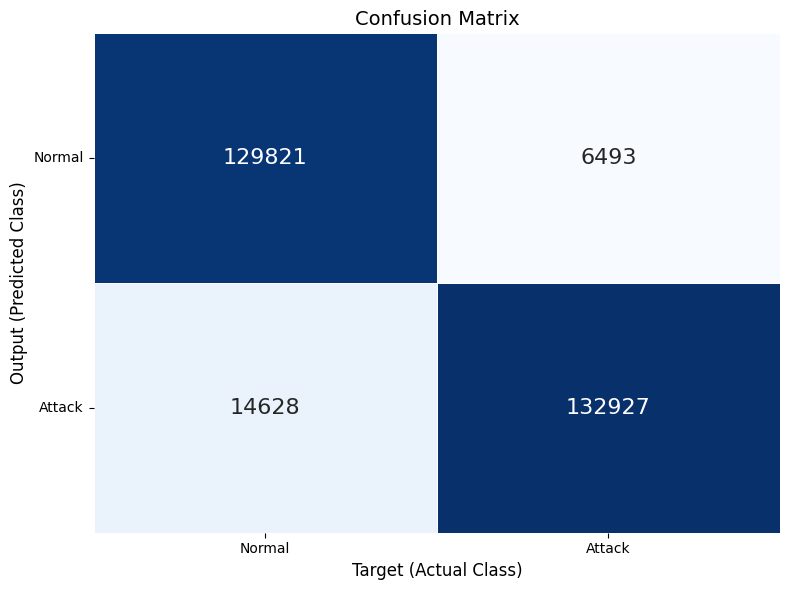

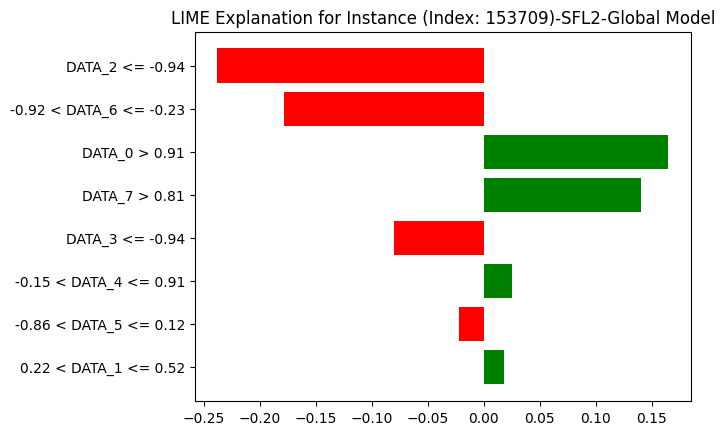

LIME explanation plot saved to /content/drive/MyDrive/car_hacking_results/SFL2-debugging_exp2-02-15-2025/lime_resultslime_explanation_SFL2.png
Total time taken for Lime Explanation: 1.53 seconds


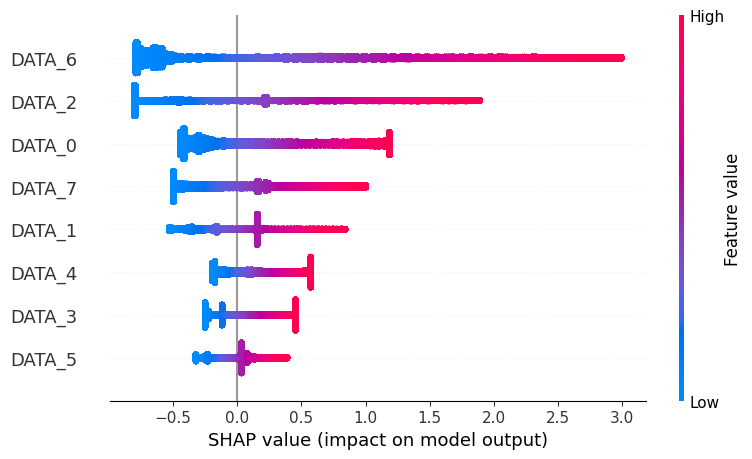

SHAP summary plot saved as /content/drive/MyDrive/car_hacking_results/SFL2-debugging_exp2-02-15-2025/shap_results/shap_summary_SFL2.png
Total time taken for Shap Explanation: 970.91 seconds


In [ ]:
results=run_fl_training(cfg, cloud_server, edge_servers,raw_train_loader, testloader, X_train_tensor, X_test_tensor, method_name="SFL2", save_path="model_checkpoint")

## Loss Plot

In [1]:
import pandas as pd
import matplotlib.pyplot as plt  # Fixed alias
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


columns of results dataframe ['Round', 'Loss', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Total Round Time', 'Edge Results', 'Train_Loss', 'Test_loss', 'FL Time', 'Confusion Matrix', 'Round Times', 'Testing Time']


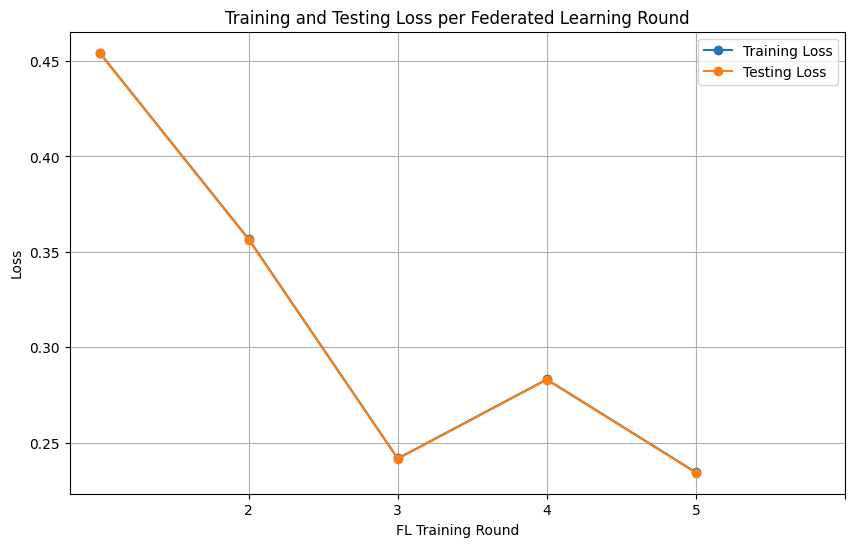

In [5]:
method_name = "SFL2"
results_path = f"/content/drive/MyDrive/car_hacking_results/SFL2-debugging_exp2-02-15-2025/results"
#results_path="/content/drive/MyDrive/car_hacking_results/SFL2-debugging-13-02-2025/results"
path = os.path.join(results_path, f"{method_name}_results.csv")

# Check if file exists
if not os.path.exists(path):
    raise FileNotFoundError(f"CSV file not found: {path}")

# Read CSV
results = pd.read_csv(path)

print("columns of results dataframe",results.columns.to_list())

# Ensure 'Round' column is numeric
df_plot = results[pd.to_numeric(results['Round'], errors='coerce').notnull()]

# Plotting training and test loss
plt.figure(figsize=(10, 6))
plt.plot(df_plot['Round'], df_plot['Train_Loss'], label="Training Loss", marker='o')
plt.plot(df_plot['Round'], df_plot['Test_loss'], label="Testing Loss", marker='o')
plt.xlabel("FL Training Round")
plt.ylabel("Loss")
plt.title("Training and Testing Loss per Federated Learning Round")
plt.xticks(df_plot['Round'].astype(int))  # Display only integer round numbers
plt.legend()
plt.grid(True)

# Save the plot
plot_path = os.path.join(results_path, f"{method_name}.png")
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

